<div style="text-align: center; font-size: 50px; font-family: Arial">
    📈Predicting Stock Prices with an LSTM Model📉 
</div>

In [95]:
import tensorflow as tf
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler


In [96]:
import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.metrics import mean_squared_error

In [99]:
def predict_stock(ticker,start_date,end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    # Select closing prices
    closing_prices = data['Close'].values.reshape(-1, 1)

    # Normalize the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    closing_prices_scaled = scaler.fit_transform(closing_prices)

    # Split the data into train/test/val sets
    train_size = int(len(closing_prices_scaled) * 0.7)
    train_data=closing_prices_scaled[:train_size]  
    test_data = closing_prices_scaled[train_size:]
    
    def create_sequences(X, sequence_length):
        Xs, ys = [], []
        for i in range(len(X) - sequence_length):
            Xs.append(X[i:i+sequence_length])
            ys.append(X[i+sequence_length]) 
        return np.array(Xs), np.array(ys)

    # Creating a data structure with 80 timesteps and 1 output
    sequence_length = 80

    X_train_seq, y_train_seq = create_sequences(train_data, sequence_length)
    X_test_seq, y_test_seq = create_sequences(test_data, sequence_length)
    # Reshaping
    X_train_seq = np.reshape(X_train_seq, (X_train_seq.shape[0], X_train_seq.shape[1], 1))
    X_train_seq
    # model
    model = Sequential()
    model.add(LSTM(50, input_shape=(X_train_seq.shape[1],X_train_seq.shape[2],))) # 10 lstm neuron(block)
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    model.fit(X_train_seq,y_train_seq, epochs=50, batch_size=32)

    # Evaluate the model
    train_loss = model.evaluate(X_train_seq,y_train_seq, verbose=0)
    test_loss = model.evaluate(X_test_seq, y_test_seq, verbose=0)
    print(f'Train Loss: {train_loss:.6f}')
    print(f'Test Loss: {test_loss:.6f}')

    trainPredict = model.predict(X_train_seq)
    testPredict = model.predict(X_test_seq)

    # Denormalize the predictions
    train_predictions = scaler.inverse_transform(trainPredict)
    y_train_unscaled = scaler.inverse_transform(y_train_seq)
    test_predictions = scaler.inverse_transform(testPredict)
    y_test_unscaled = scaler.inverse_transform(y_test_seq)

    # Empty array to contain  all predictions
    predictions_plot = np.empty_like(closing_prices)
    predictions_plot[:, :] = np.nan

    # Indices de début pour les prédictions train/test
    train_prediction_start = sequence_length
    test_prediction_start = len(train_data) + sequence_length  # CORRIGÉ ICI

    # Insérer les prédictions dans le tableau global
    predictions_plot[train_prediction_start:train_prediction_start + len(train_predictions), 0] = train_predictions[:, 0]
    predictions_plot[test_prediction_start:test_prediction_start + len(test_predictions), 0] = test_predictions[:, 0]

    # Plot
    plt.figure(figsize=(14,6))
    plt.plot(data.index, closing_prices, label='Real prices')
    plt.plot(data.index, predictions_plot, label='Predictions', linestyle='--')
    plt.axvline(x=data.index[len(train_data)], color='red', linestyle=':', label='Train/Test Limit')
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title(f"{ticker} Stock Price Evolution – Actual vs Predictions")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


[*********************100%***********************]  1 of 1 completed

Epoch 1/50



C:\Users\okouo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0490
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.8829e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.3484e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.5175e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.7066e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.5949e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.5804e-04
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.1999e-04
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.2864e-04
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.3327e-04
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.2612e-04
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.2478e-04
Epoch 13/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.9200e-04
Epoch 14/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.2474e-04
Epoch 15/50
44/44 ━━━━━━━━━━━━

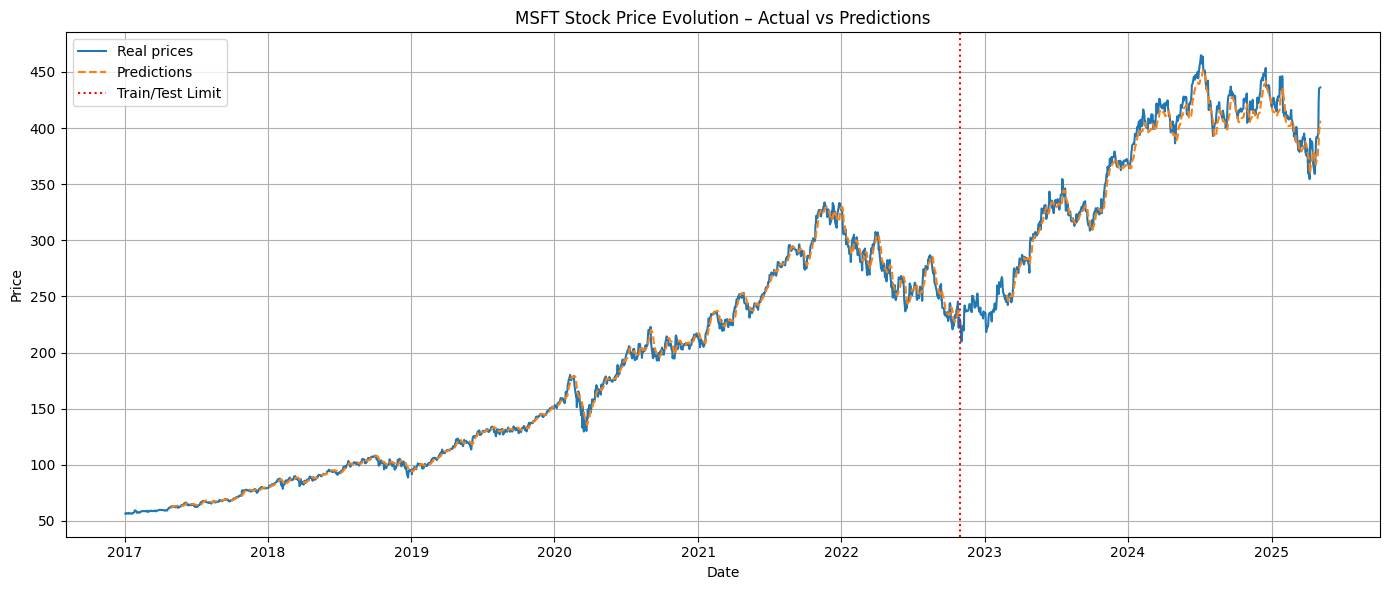

In [100]:
predict_stock('MSFT',"2017-01-01",date.today())

# Apple'stock

Data collection

In [68]:
import yfinance as yf

# Define the ticker symbol
ticker_symbol = "AAPL"

# Create a Ticker object
ticker = yf.Ticker(ticker_symbol)

# Fetch historical market data
historical_data = ticker.history(period="1y")  # data for the last year
print("Historical Data:")
print(historical_data)

# Fetch basic financials
financials = ticker.financials
print("\nFinancials:")
print(financials)

# Fetch stock actions like dividends and splits
actions = ticker.actions
print("\nStock Actions:")
print(actions)

Historical Data:
                                 Open        High         Low       Close  \
Date                                                                        
2024-05-06 00:00:00-04:00  181.493040  183.334337  179.572103  180.856049   
2024-05-07 00:00:00-04:00  182.587854  184.031037  180.467875  181.542786   
2024-05-08 00:00:00-04:00  181.990663  182.209631  180.597234  181.881180   
2024-05-09 00:00:00-04:00  181.702043  183.792180  181.254160  183.702606   
2024-05-10 00:00:00-04:00  184.280638  184.470004  181.519927  182.436844   
...                               ...         ...         ...         ...   
2025-04-30 00:00:00-04:00  209.300003  213.580002  206.669998  212.500000   
2025-05-01 00:00:00-04:00  209.080002  214.559998  208.899994  213.320007   
2025-05-02 00:00:00-04:00  206.089996  206.990005  202.160004  205.350006   
2025-05-05 00:00:00-04:00  203.100006  204.100006  198.210007  198.889999   
2025-05-06 00:00:00-04:00  198.125000  200.649002  197.0200

In [69]:
# Download historical price data from Yahoo Finance in a dataset

ticker = "AAPL"  # Apple stock symbol
start_date = "2015-01-01"
end_date = date.today()
data = yf.download(ticker, start=start_date, end=end_date)

# Select closing prices
closing_prices = data['Close'].values.reshape(-1, 1)
closing_prices

[*********************100%***********************]  1 of 1 completed


array([[ 24.32043457],
       [ 23.63528824],
       [ 23.63751221],
       ...,
       [213.32000732],
       [205.3500061 ],
       [198.88999939]])

In [70]:
data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.320435,24.789804,23.879983,24.778681,212818400
2015-01-05,23.635288,24.169168,23.448431,24.089086,257142000
2015-01-06,23.637512,23.897778,23.274918,23.699798,263188400
2015-01-07,23.968964,24.069065,23.735391,23.846616,160423600
2015-01-08,24.889904,24.947741,24.180289,24.298189,237458000
...,...,...,...,...,...
2025-04-29,211.210007,212.240005,208.369995,208.690002,36827600
2025-04-30,212.500000,213.580002,206.669998,209.300003,52286500


Data preprocessing

In [71]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
closing_prices_scaled = scaler.fit_transform(closing_prices)
closing_prices_scaled

array([[0.015315  ],
       [0.01243697],
       [0.01244631],
       ...,
       [0.80922746],
       [0.77574863],
       [0.7486127 ]])

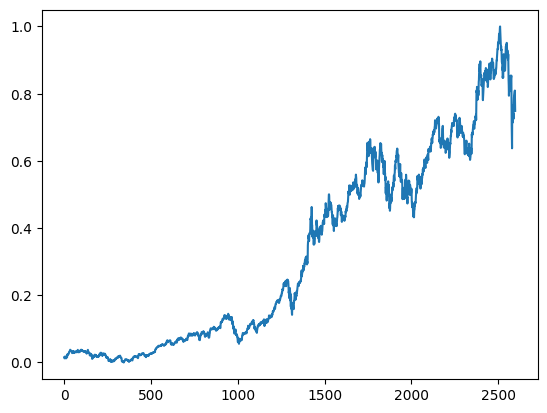

In [72]:
plt.plot(closing_prices_scaled)
plt.show()

In [73]:
# Split the data into train/test/val sets
train_size = int(len(closing_prices_scaled) * 0.7)
train_data=closing_prices_scaled[:train_size]  
test_data = closing_prices_scaled[train_size:]
print(len(closing_prices_scaled),len(train_data),len(test_data))

2600 1819 781


In [74]:
def create_sequences(X, sequence_length):
    Xs, ys = [], []
    for i in range(len(X) - sequence_length):
        Xs.append(X[i:i+sequence_length])
        ys.append(X[i+sequence_length]) 
    return np.array(Xs), np.array(ys)

In [86]:
# Creating a data structure with 50 timesteps and 1 output
sequence_length = 80

X_train_seq, y_train_seq = create_sequences(train_data, sequence_length)
X_test_seq, y_test_seq = create_sequences(test_data, sequence_length)

In [87]:
# Reshaping
X_train_seq = np.reshape(X_train_seq, (X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_train_seq

array([[[0.015315  ],
        [0.01243697],
        [0.01244631],
        ...,
        [0.03537159],
        [0.03759493],
        [0.03563428]],

       [[0.01243697],
        [0.01244631],
        [0.0138386 ],
        ...,
        [0.03759493],
        [0.03563428],
        [0.03383308]],

       [[0.01244631],
        [0.0138386 ],
        [0.01770711],
        ...,
        [0.03563428],
        [0.03383308],
        [0.03055908]],

       ...,

       [[0.57951388],
        [0.581702  ],
        [0.56052348],
        ...,
        [0.57283968],
        [0.5770974 ],
        [0.59098632]],

       [[0.581702  ],
        [0.56052348],
        [0.57468366],
        ...,
        [0.5770974 ],
        [0.59098632],
        [0.59677337]],

       [[0.56052348],
        [0.57468366],
        [0.59557317],
        ...,
        [0.59098632],
        [0.59677337],
        [0.6109931 ]]])

In [88]:
y_train_seq

array([[0.03383308],
       [0.03055908],
       [0.03412389],
       ...,
       [0.59677337],
       [0.6109931 ],
       [0.61673874]])

LSTM model

In [89]:
import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.metrics import mean_squared_error

In [90]:
# model
model = Sequential()
model.add(LSTM(50, input_shape=(X_train_seq.shape[1],X_train_seq.shape[2],))) # 10 lstm neuron(block)
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train_seq,y_train_seq, epochs=50, batch_size=32)


Epoch 1/50


C:\Users\okouo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0306
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.6506e-04
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.2012e-04
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.8850e-04
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.0497e-04
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.8531e-04
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.6892e-04
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.5360e-04
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.6822e-04
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.7208e-04
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.4807e-04
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.6223e-04
Epoch 13/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.6137e-04
Epoch 14/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.4728e-04
Epoch 15/50
55/55 ━━━━━━━━━━━━

In [91]:
# Evaluate the model
train_loss = model.evaluate(X_train_seq,y_train_seq, verbose=0)
test_loss = model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f'Train Loss: {train_loss:.6f}')
print(f'Test Loss: {test_loss:.6f}')

Train Loss: 0.000126
Test Loss: 0.000598


predictions and visualization

In [92]:
trainPredict = model.predict(X_train_seq)
testPredict = model.predict(X_test_seq)

# Denormalize the predictions
train_predictions = scaler.inverse_transform(trainPredict)
y_train_unscaled = scaler.inverse_transform(y_train_seq)
test_predictions = scaler.inverse_transform(testPredict)
y_test_unscaled = scaler.inverse_transform(y_test_seq)



55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


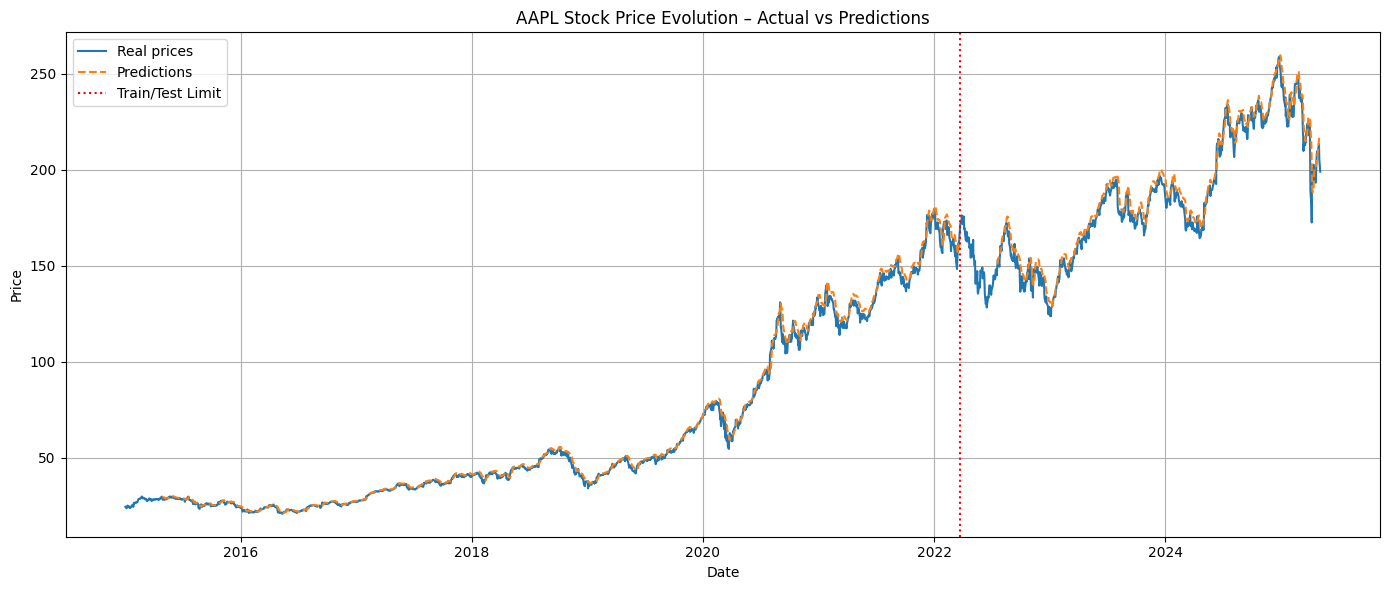

In [93]:
# Empty array to contain  all predictions
predictions_plot = np.empty_like(closing_prices)
predictions_plot[:, :] = np.nan

# Indices de début pour les prédictions train/test
train_prediction_start = sequence_length
test_prediction_start = len(train_data) + sequence_length  # CORRIGÉ ICI

# Insérer les prédictions dans le tableau global
predictions_plot[train_prediction_start:train_prediction_start + len(train_predictions), 0] = train_predictions[:, 0]
predictions_plot[test_prediction_start:test_prediction_start + len(test_predictions), 0] = test_predictions[:, 0]

# Plot
plt.figure(figsize=(14,6))
plt.plot(data.index, closing_prices, label='Real prices')
plt.plot(data.index, predictions_plot, label='Predictions', linestyle='--')
plt.axvline(x=data.index[len(train_data)], color='red', linestyle=':', label='Train/Test Limit')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("AAPL Stock Price Evolution – Actual vs Predictions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
